# Oceanography: Ocean Thermal Structure

**Question:** How does ocean temperature change with depth?

Reference notebook for The Pond. All observations and locations are **synthetic**, created for this activity; results are not evidence about a real site.

## Preamble: From sketch to notebook

In a previous [LiLyPad](https://linked.earth/ThePond/lilypads/workflow/sketching-workflows/index.html), you sketched a workflow to investigate how ocean temperature changes with depth.

Here, we use several temperature profiles collected at the same location to investigate that question. We will standardize the measurement units, retain valid observations from the upper 500 meters, and calculate the average temperature within 10-meter depth intervals.

In this notebook, we will translate that sketch into a computational workflow. As you work through each section, notice:

- What data does the step receive?
- What operation does it perform?
- What parameters or decisions control that operation?
- What does it produce, and which step uses that output?

An output does not need to be saved as a separate file. It can be a table or another object held in memory, provided we explain what it contains and how it is used.

Follow each input → analysis → output connection in your sketch. Markdown explains meaning, documents choices, and describes manual steps; code performs computational operations; displayed tables and figures let us inspect the results.

<div class="alert alert-block alert-info">
    <b>Note:</b> A notebook’s preamble introduces the scientific questions it addresses and explains how its analyses fit into the broader study. It is also a useful place to document data sources and software dependencies, including their versions.
</div>

## Exploratory Data Analysis

Let's first load our data and understand how it is organized.

Each row is one temperature measurement at a particular depth. `profile` identifies the profile to which the measurement belongs. A profile is a series of measurements collected at different depths through the water column.

`depth` gives the measurement depth, and `depth_unit` indicates whether it is reported in meters (`m`) or centimeters (`cm`). Depth increases downward from the ocean surface. `temperature` gives the measured temperature, with `temperature_unit` indicating degrees Celsius (`C`) or kelvin (`K`).

The `QA` column records the quality-control result: 0 indicates a valid measurement, 1 indicates an invalid measurement, and a blank indicates that the measurement has not been checked.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("data/oceanography.csv")

print(f"Input: {len(raw)} measurements")
display(raw.head())

Input: 452 measurements


,profile,depth,depth_unit,temperature,temperature_unit,QA
0,P1,0,m,22.888245,C,1.0
1,P1,5,m,21.942430,C,0.0
2,P1,10,m,21.848151,C,0.0
3,P1,15,m,20.977422,C,0.0
4,P1,20,m,20.106926,C,0.0


## Data Pre-Processing

Our first step is to express all depths in meters. Measurements reported in centimeters are divided by 100, while those already in meters remain unchanged.

We retain the original columns and add `depth_m` to store the converted depths.

In [2]:
depths = raw.copy()

depths["depth_m"] = (
    depths["depth"]
    * depths["depth_unit"].map({"m": 1, "cm": 0.01})
)

assert depths["depth_m"].notna().all()

display(depths[["profile", "depth", "depth_unit", "depth_m"]].head())

,profile,depth,depth_unit,depth_m
0,P1,0,m,0.0
1,P1,5,m,5.0
2,P1,10,m,10.0
3,P1,15,m,15.0
4,P1,20,m,20.0


We next express all temperatures in degrees Celsius. For measurements reported in kelvin, we subtract 273.15. Values already reported in degrees Celsius remain unchanged.

We store the converted temperatures in `temperature_C`. The resulting table now contains depths in meters and temperatures in degrees Celsius, alongside the original measurements.

In [3]:
standardized = depths.copy()

standardized["temperature_C"] = (
    standardized["temperature"]
    - standardized["temperature_unit"].map({"C": 0, "K": 273.15})
)

assert standardized["temperature_C"].notna().all()

display(
    standardized[
        ["profile", "depth_m", "temperature", "temperature_unit", "temperature_C"]
    ].head()
)

,profile,depth_m,temperature,temperature_unit,temperature_C
0,P1,0.0,22.888245,C,22.888245
1,P1,5.0,21.942430,C,21.942430
2,P1,10.0,21.848151,C,21.848151
3,P1,15.0,20.977422,C,20.977422
4,P1,20.0,20.106926,C,20.106926


We now retain only measurements marked as valid in the `QA` column. In this dataset, a flag of 0 indicates a valid measurement. We exclude both measurements marked as invalid (1) and those with no recorded quality-control result.

The resulting dataset contains valid temperature measurements with depths in meters and temperatures in degrees Celsius.

In [4]:
quality = standardized.loc[
    standardized["QA"].eq(0)
].copy()

print(f"{len(standardized)} measurements → {len(quality)} valid measurements")
display(quality.head())

452 measurements → 412 valid measurements


,profile,depth,depth_unit,temperature,temperature_unit,QA,depth_m,temperature_C
1,P1,5,m,21.942430,C,0.0,5.0,21.942430
2,P1,10,m,21.848151,C,0.0,10.0,21.848151
3,P1,15,m,20.977422,C,0.0,15.0,20.977422
4,P1,20,m,20.106926,C,0.0,20.0,20.106926
5,P1,25,m,19.276368,C,0.0,25.0,19.276368


We restrict our analysis to the upper 500 meters of the ocean. Measurements at the surface (0 m) and exactly 500 m deep are included.

The resulting dataset contains valid temperature measurements within our selected depth range.

In [5]:
MAX_DEPTH_M = 500

upper = quality.loc[
    quality["depth_m"].between(0, MAX_DEPTH_M)
].copy()

print(f"{len(quality)} valid measurements → {len(upper)} in the upper 500 m")
display(upper.head())

412 valid measurements → 364 in the upper 500 m


,profile,depth,depth_unit,temperature,temperature_unit,QA,depth_m,temperature_C
1,P1,5,m,21.942430,C,0.0,5.0,21.942430
2,P1,10,m,21.848151,C,0.0,10.0,21.848151
3,P1,15,m,20.977422,C,0.0,15.0,20.977422
4,P1,20,m,20.106926,C,0.0,20.0,20.106926
5,P1,25,m,19.276368,C,0.0,25.0,19.276368


## Analysis

We divide the upper 500 meters into 10-meter depth intervals and calculate the mean temperature within each interval. We combine measurements from all profiles, giving each retained measurement equal weight.

Intervals include their shallow boundary and exclude their deep boundary: a measurement at 10 m belongs to the 10–20 m interval. The final interval also includes measurements at exactly 500 m.

The resulting table contains one row per depth interval, with its mean temperature, number of measurements, and midpoint depth for plotting.

<div class="alert alert-block alert-info">
    <b>Note:</b> Averaging all measurements gives more weight to profiles with more observations in an interval. This differs from first calculating a mean for each profile and then averaging those means. We document our choice because the two approaches can produce different results. Intervals without measurements retain a missing mean; we do not interpolate across them.
</div>

In [6]:
BIN_M = 10
N_BINS = MAX_DEPTH_M // BIN_M

binned = upper.copy()

# Assign measurements to intervals, including 500 m in the final interval.
binned["bin_index"] = np.minimum(
    (binned["depth_m"] // BIN_M).astype(int),
    N_BINS - 1
)

profile_mean = (
    binned.groupby("bin_index")
    .agg(
        mean_temperature_C=("temperature_C", "mean"),
        n=("temperature_C", "size")
    )
    .reindex(range(N_BINS))
)

profile_mean["midpoint_m"] = (profile_mean.index + 0.5) * BIN_M
profile_mean["n"] = profile_mean["n"].fillna(0).astype(int)

assert profile_mean["n"].sum() == len(upper)

display(profile_mean.head())

,mean_temperature_C,n,midpoint_m
bin_index,,,
0,22.223084,4,5.0
1,21.172089,8,15.0
2,19.634475,8,25.0
3,18.430280,8,35.0
4,17.293971,8,45.0


## Visualization

Let's plot the mean temperature for each depth interval at its midpoint. We place temperature on the horizontal axis and depth on the vertical axis, increasing downward to match the water column.

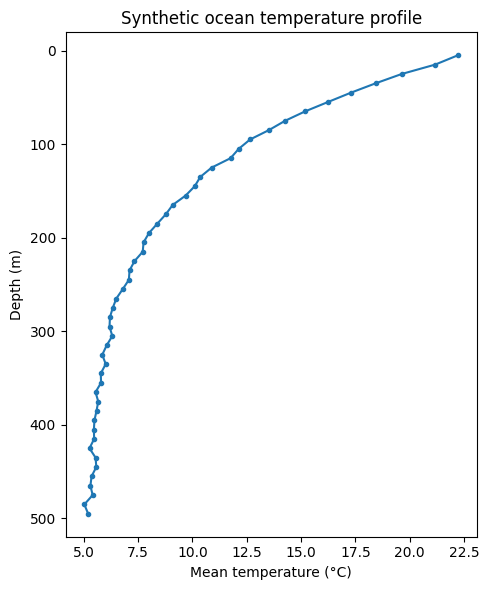

In [7]:
fig, ax = plt.subplots(figsize=(5, 6))

ax.plot(
    profile_mean["mean_temperature_C"],
    profile_mean["midpoint_m"],
    "o-",
    markersize=3
)

ax.invert_yaxis()

ax.set(
    xlabel="Mean temperature (°C)",
    ylabel="Depth (m)",
    title="Synthetic ocean temperature profile"
)

fig.tight_layout()

In these synthetic observations, mean temperature decreases with depth, with the strongest change near the surface.

Our profile summarizes measurements across several profiles. The 10-meter intervals smooth some of the vertical detail, and averaging across profiles can hide differences between individual profiles.

<details>
<summary><strong>Show the reference workflow</strong></summary>

![Reference workflow for the oceanography scenario](./figures/oceanography-workflow-answer.png)

</details>